# Detect Sound Units
Loads the synthesized audio and automatically finds where each sound unit begins and ends.
See `docs/detect_units.md` for theory.

## Imports

In [2]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Audio, display
import json

print('ready')

ready


## Load the audio file

In [3]:
sample_rate, data = wav.read('../audio/rocky_voice.wav')

# convert int16 back to float in range [-1, 1]
audio = data.astype(np.float64) / 32767.0

duration = len(audio) / sample_rate
print(f'sample rate : {sample_rate} Hz')
print(f'samples     : {len(audio):,}')
print(f'duration    : {duration:.2f}s')
display(Audio(audio, rate=sample_rate))

sample rate : 44100 Hz
samples     : 358,973
duration    : 8.14s


## Compute RMS energy over time
Slide a short window across the audio and measure loudness at each position.

In [4]:
WINDOW  = 512   # samples per window (~11ms at 44100 Hz)
HOP     = 128   # step between windows (~3ms) — overlap gives smoother curve

def compute_rms(audio, window, hop):
    frames = []
    for i in range(0, len(audio) - window, hop):
        frame = audio[i : i + window]
        rms = np.sqrt(np.mean(frame ** 2))  # root mean square = loudness
        frames.append(rms)
    return np.array(frames)

rms = compute_rms(audio, WINDOW, HOP)

# time axis for plotting
rms_times = np.arange(len(rms)) * HOP / sample_rate

print(f'RMS frames computed: {len(rms)}')
print(f'each frame covers  : {HOP/sample_rate*1000:.1f}ms')

RMS frames computed: 2801
each frame covers  : 2.9ms


## Compute onset strength
How sharply does the energy rise at each frame? A sudden rise = a new sound starting.

In [5]:
# onset strength = positive differences in RMS (only rising edges)
onset_strength = np.diff(rms, prepend=rms[0])
onset_strength = np.clip(onset_strength, 0, None)  # keep only rises, zero out falls

print(f'max onset strength : {onset_strength.max():.4f}')
print(f'mean onset strength: {onset_strength.mean():.4f}')

max onset strength : 0.3330
mean onset strength: 0.0069


## Find onset peaks — where new sounds begin

In [6]:
from scipy.signal import find_peaks

THRESHOLD    = onset_strength.max() * 0.15  # minimum height to count as onset
MIN_GAP_SEC  = 0.05                          # minimum seconds between two onsets
MIN_GAP_FRAMES = int(MIN_GAP_SEC * sample_rate / HOP)

peaks, _ = find_peaks(onset_strength, height=THRESHOLD, distance=MIN_GAP_FRAMES)

onset_times = rms_times[peaks]  # convert frame indices to seconds

print(f'onsets detected : {len(peaks)}')
print(f'onset times (s) : {[round(t, 3) for t in onset_times]}')

onsets detected : 28
onset times (s) : [np.float64(0.102), np.float64(0.223), np.float64(0.551), np.float64(0.772), np.float64(1.309), np.float64(1.672), np.float64(1.791), np.float64(1.913), np.float64(2.148), np.float64(2.781), np.float64(3.007), np.float64(3.242), np.float64(3.556), np.float64(3.666), np.float64(3.776), np.float64(4.304), np.float64(4.365), np.float64(4.432), np.float64(4.583), np.float64(4.897), np.float64(5.03), np.float64(5.3), np.float64(6.078), np.float64(6.319), np.float64(6.647), np.float64(7.024), np.float64(7.242), np.float64(7.369)]


## Visualize — waveform with detected onsets marked

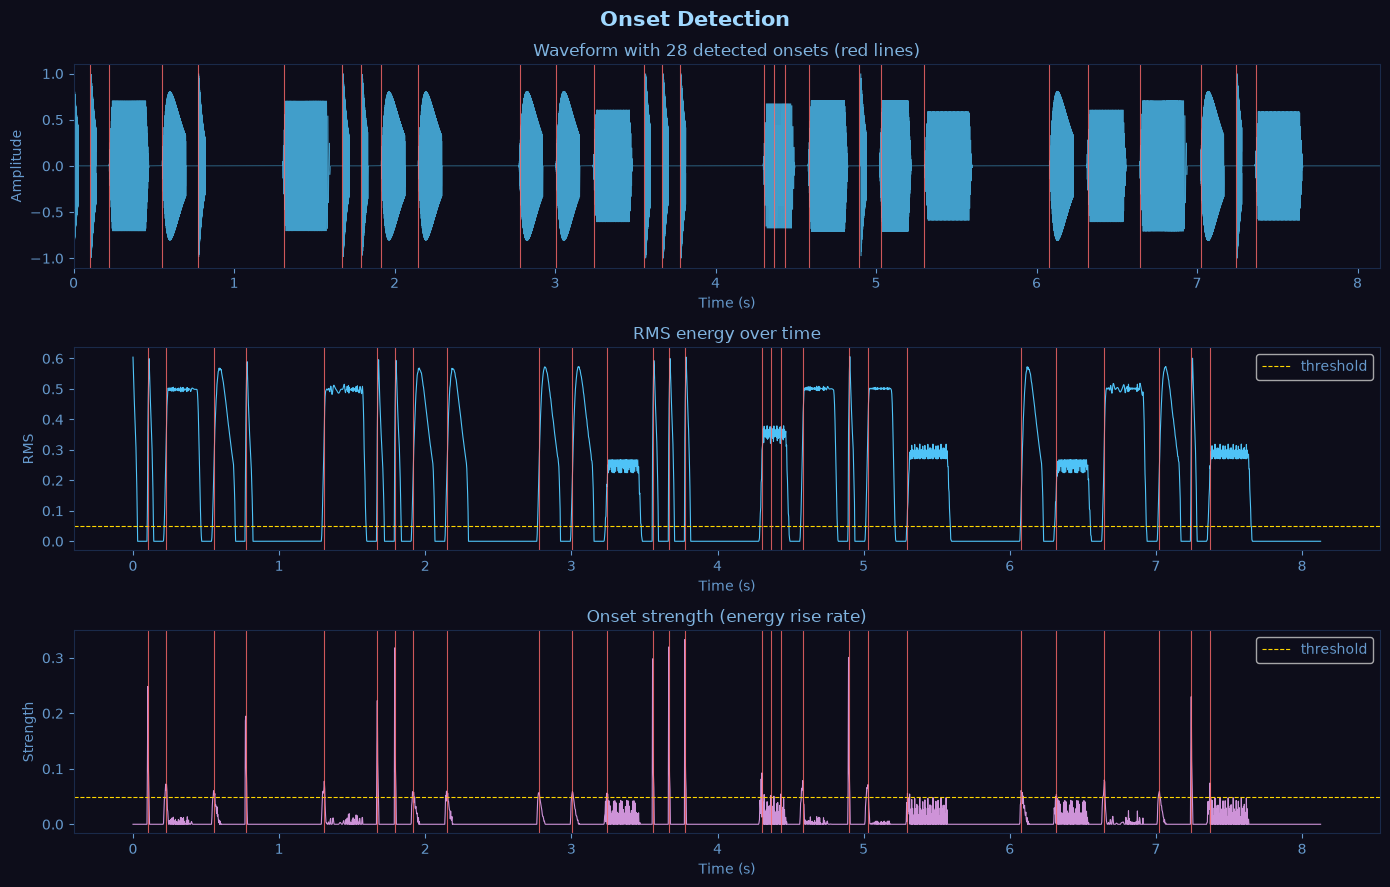

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), facecolor='#0d0d1a')
fig.suptitle("Onset Detection", color='#a0d8ff', fontsize=15, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#6699cc')
    ax.xaxis.label.set_color('#6699cc')
    ax.yaxis.label.set_color('#6699cc')
    for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

t_axis = np.linspace(0, duration, len(audio))

# waveform with onset markers
axes[0].plot(t_axis, audio, color='#4fc3f7', linewidth=0.4, alpha=0.8)
for t in onset_times:
    axes[0].axvline(x=t, color='#ff6b6b', linewidth=0.8, alpha=0.8)
axes[0].set(title=f'Waveform with {len(peaks)} detected onsets (red lines)',
            xlabel='Time (s)', ylabel='Amplitude', xlim=(0, duration))
axes[0].title.set_color('#80b4e0')

# RMS energy curve
axes[1].plot(rms_times, rms, color='#4fc3f7', linewidth=0.8)
axes[1].axhline(y=THRESHOLD, color='#ffd700', linewidth=0.8, linestyle='--', label='threshold')
for t in onset_times:
    axes[1].axvline(x=t, color='#ff6b6b', linewidth=0.8, alpha=0.8)
axes[1].set(title='RMS energy over time', xlabel='Time (s)', ylabel='RMS')
axes[1].title.set_color('#80b4e0')
axes[1].legend(facecolor='#0d0d1a', labelcolor='#6699cc')

# onset strength curve
axes[2].plot(rms_times, onset_strength, color='#ce93d8', linewidth=0.8)
axes[2].axhline(y=THRESHOLD, color='#ffd700', linewidth=0.8, linestyle='--', label='threshold')
for t in onset_times:
    axes[2].axvline(x=t, color='#ff6b6b', linewidth=0.8, alpha=0.8)
axes[2].set(title='Onset strength (energy rise rate)', xlabel='Time (s)', ylabel='Strength')
axes[2].title.set_color('#80b4e0')
axes[2].legend(facecolor='#0d0d1a', labelcolor='#6699cc')

plt.tight_layout()
plt.savefig('../audio/onset_detection.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

## Slice audio into individual units
Use onset times as cut points. Each slice = one detected sound unit.

In [8]:
OFFSET_SEC = 0.01   # start slice slightly before the onset marker
MAX_DUR    = 0.5    # maximum duration of one unit in seconds

units = []
for i, onset_t in enumerate(onset_times):
    start = max(0, int((onset_t - OFFSET_SEC) * sample_rate))
    # end = next onset or max duration, whichever comes first
    if i + 1 < len(onset_times):
        end = int(onset_times[i + 1] * sample_rate)
    else:
        end = min(len(audio), start + int(MAX_DUR * sample_rate))
    units.append(audio[start:end])

print(f'units extracted: {len(units)}')
for i, u in enumerate(units):
    print(f'  unit {i:02d}  {len(u)/sample_rate*1000:.0f}ms')

units extracted: 28
  unit 00  132ms
  unit 01  338ms
  unit 02  231ms
  unit 03  547ms
  unit 04  373ms
  unit 05  129ms
  unit 06  132ms
  unit 07  245ms
  unit 08  643ms
  unit 09  236ms
  unit 10  245ms
  unit 11  323ms
  unit 12  120ms
  unit 13  120ms
  unit 14  538ms
  unit 15  71ms
  unit 16  77ms
  unit 17  161ms
  unit 18  323ms
  unit 19  144ms
  unit 20  280ms
  unit 21  788ms
  unit 22  251ms
  unit 23  338ms
  unit 24  387ms
  unit 25  228ms
  unit 26  138ms
  unit 27  500ms


## Listen to each detected unit

In [9]:
def normalize(audio):
    peak = np.max(np.abs(audio))
    return audio / peak if peak > 0 else audio

for i, unit in enumerate(units[:15]):  # preview first 15
    print(f'unit {i:02d}')
    display(Audio(normalize(unit), rate=sample_rate))

unit 00


unit 01


unit 02


unit 03


unit 04


...

unit 10


unit 11


unit 12


unit 13


unit 14


## Extract features from each unit
Turn each audio slice into a set of numbers that describe it — used for clustering next.

In [10]:
def extract_features(audio_slice, sr):
    """
    Four numbers that characterize a sound unit:
    - dominant frequency : the loudest pitch present (Hz)
    - duration           : how long it lasts (seconds)
    - mean RMS           : average loudness
    - spectral centroid  : weighted average frequency (brightness)
    """
    # dominant frequency via FFT
    fft_vals  = np.abs(np.fft.rfft(audio_slice))
    fft_freqs = np.fft.rfftfreq(len(audio_slice), d=1/sr)
    dominant_freq = fft_freqs[np.argmax(fft_vals)]

    # duration
    duration = len(audio_slice) / sr

    # mean RMS
    mean_rms = np.sqrt(np.mean(audio_slice ** 2))

    # spectral centroid — frequency weighted by amplitude
    centroid = np.sum(fft_freqs * fft_vals) / (np.sum(fft_vals) + 1e-9)

    return [dominant_freq, duration, mean_rms, centroid]

features = np.array([extract_features(u, sample_rate) for u in units])

print(f'feature matrix shape: {features.shape}  ({len(units)} units × 4 features)')
print()
print(f'{"unit":6} {"dom_freq":>10} {"duration":>10} {"rms":>10} {"centroid":>10}')
for i, f in enumerate(features):
    print(f'{i:6} {f[0]:10.1f} {f[1]:10.4f} {f[2]:10.4f} {f[3]:10.1f}')

feature matrix shape: (28, 4)  (28 units × 4 features)

unit     dom_freq   duration        rms   centroid
     0     2403.2     0.1319     0.2312     2827.3
     1      452.7     0.3380     0.4050      582.0
     2      732.9     0.2306     0.3490     1034.3
     3     1201.2     0.5470     0.1197     1858.3
     4      209.2     0.3728     0.4266      203.1
     5     1201.5     0.1290     0.2439     1565.7
     6      598.9     0.1319     0.2369      873.0
     7      762.9     0.2451     0.3385     1055.9
     8      712.6     0.6427     0.2092     1067.4
     9     1256.4     0.2364     0.3468     1059.6
    10     1277.0     0.2451     0.3406     1058.5
    11      998.5     0.3235     0.2083      675.6
    12     2402.4     0.1203     0.2434     2851.7
    13     2402.4     0.1203     0.2434     2851.7
    14     2402.3     0.5382     0.1159     2659.4
    15      451.0     0.0710     0.3171      806.2
    16      299.7     0.0767     0.3537     2387.7
    17      298.3     0.16

## Save units and features

In [11]:
np.save('../data/unit_features.npy', features)
np.save('../data/onset_times.npy', onset_times)

# save unit boundaries to dictionary
with open('../data/dictionary.json', 'r') as f:
    dictionary = json.load(f)

dictionary['units_detected'] = len(units)
dictionary['onset_times']    = onset_times.tolist()

with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)

print(f'saved  data/unit_features.npy   shape {features.shape}')
print(f'saved  data/onset_times.npy     {len(onset_times)} onsets')
print(f'saved  data/dictionary.json     updated')


saved  data/unit_features.npy   shape (28, 4)
saved  data/onset_times.npy     28 onsets
saved  data/dictionary.json     updated
